In [1]:
#import the packages required to find pearson coefficient
import os
import numpy as np  
from scipy.stats import pearsonr
from pathlib import Path

In [2]:
data_dir = [
    './yearly_data_evaporation',
    './yearly_data_rainfall',
    './yearly_data_soil_moisture',
    './yearly_data_surface_solar_rad',
    './yearly_data_u_component',
    './yearly_data_v_component'
]
print(len(data_dir))

6


In [3]:
#find number of files in each dir of data_dir
for dir in data_dir:
    path = Path(dir)
    files = list(path.glob('*.npy'))
    print(f'{dir}: {len(files)} files')

./yearly_data_evaporation: 20 files
./yearly_data_rainfall: 20 files
./yearly_data_soil_moisture: 20 files
./yearly_data_surface_solar_rad: 20 files
./yearly_data_u_component: 20 files
./yearly_data_v_component: 20 files


In [4]:
#pearson coefficient of each feature with respect to the soil moisture
store_pearson = np.zeros(len(data_dir))
for i in range(len(data_dir)):
    if i == 2:
        continue
    else:
        path1 = Path(data_dir[i])
        path2 = Path(data_dir[2])
        files1 = list(path1.glob('*.npy'))
        files2 = list(path2.glob('*.npy'))
        avg_pearson = 0
        for file1, file2 in zip(files1, files2):
            data1 = np.load(file1)
            data2 = np.load(file2)
            coeff, _ = pearsonr(data1.flatten(), data2.flatten())
            avg_pearson += coeff
            # print(f'Pearson coefficient between {file1} and {file2}: {coeff}')
        store_pearson[i] = abs(avg_pearson / len(files1))
        print(f'Average Pearson coefficient for {data_dir[i]}: {avg_pearson / len(files1)}')


Average Pearson coefficient for ./yearly_data_evaporation: -0.0902593657374382
Average Pearson coefficient for ./yearly_data_rainfall: 0.29371732473373413
Average Pearson coefficient for ./yearly_data_surface_solar_rad: -0.3668391704559326
Average Pearson coefficient for ./yearly_data_u_component: -0.30622997879981995
Average Pearson coefficient for ./yearly_data_v_component: -0.0843934565782547


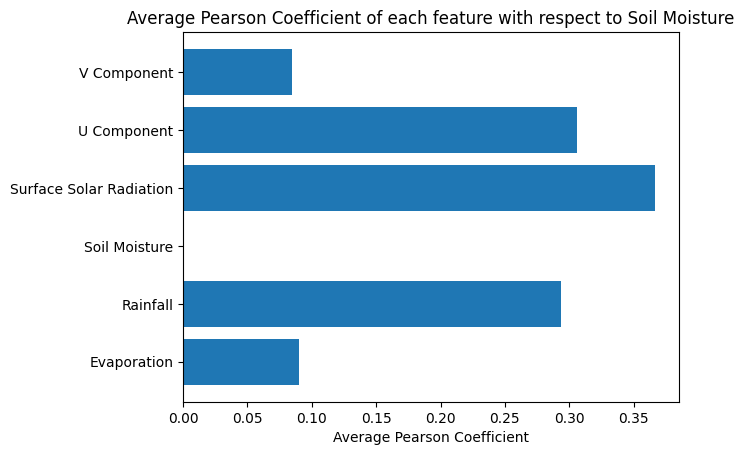

In [5]:
#plot a horizontal bar graph for each feature with respect to the soil moisture  
import matplotlib.pyplot as plt
store_pearson[2] = 0
features = ['Evaporation', 'Rainfall', 'Soil Moisture', 'Surface Solar Radiation', 'U Component', 'V Component']
plt.barh(features, store_pearson)
plt.xlabel('Average Pearson Coefficient')
plt.title('Average Pearson Coefficient of each feature with respect to Soil Moisture')
plt.show()

In [6]:
data_check = np.load('./yearly_data_surface_solar_rad/yearly_data_2001.npy')
#Max value in the 2d data of data_check[i]
print(f'Max value in the 2d data of data_check: {np.max(data_check)}')

Max value in the 2d data of data_check: 1509424.0


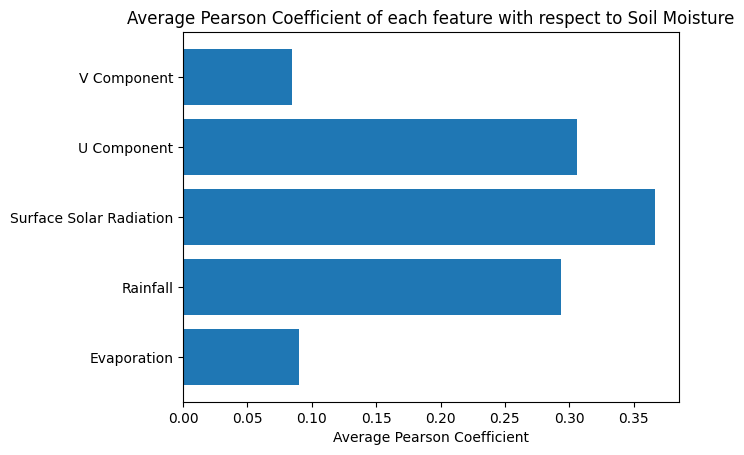

In [7]:
#plot a horizontal bar graph for each feature with respect to the soil moisture but not the the soil moisture itself
import matplotlib.pyplot as plt
store_pearson[2] = 0
features = ['Evaporation', 'Rainfall', 'Surface Solar Radiation', 'U Component', 'V Component']
plt.barh(features, np.delete(store_pearson, 2))
plt.xlabel('Average Pearson Coefficient')
plt.title('Average Pearson Coefficient of each feature with respect to Soil Moisture')
plt.show()